[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/Machine-Learning-from-scratch/blob/master/topics/01_linear_regression/exercises.ipynb)

# 01 Linear Regression — Exercises

Test your understanding of the normal equations, ridge regression, conditioning,
and the bias–variance tradeoff.

**Prerequisites.** Read [theory.md](theory.md) and work through
[first_principles.ipynb](first_principles.ipynb) before attempting these.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams["figure.dpi"] = 90

---
## Exercise 1 — Hand Calculation: Normal Equations on a 3-Point Dataset

Given the dataset of 3 points $(x, y)$:

$$(0, 1), \quad (1, 3), \quad (2, 2)$$

fit the model $\hat{y} = \theta_0 + \theta_1 x$ by hand using the normal equations
(theory §6): $\theta^\ast = (X^\top X)^{-1} X^\top y$.

**Tasks:**

1. Write the design matrix $X$ (bias trick, theory §2.3) and the target vector $y$.
2. Compute $X^\top X$ and $X^\top y$.
3. Invert the $2 \times 2$ matrix $X^\top X$ and solve for $\theta^\ast$.
4. Compute the predictions $\hat{y} = X\theta^\ast$ and residuals $r = \hat{y} - y$.
5. Verify residual orthogonality $X^\top r = 0$ (theory §7.1).

**Expected results:**

$$X = \begin{bmatrix} 1 & 0 \\ 1 & 1 \\ 1 & 2 \end{bmatrix}, \quad
y = \begin{bmatrix} 1 \\ 3 \\ 2 \end{bmatrix}, \quad
X^\top X = \begin{bmatrix} 3 & 3 \\ 3 & 5 \end{bmatrix}, \quad
X^\top y = \begin{bmatrix} 6 \\ 7 \end{bmatrix}$$

$$\det(X^\top X) = 15 - 9 = 6, \quad
(X^\top X)^{-1} = \frac{1}{6} \begin{bmatrix} 5 & -3 \\ -3 & 3 \end{bmatrix}, \quad
\theta^\ast = \frac{1}{6} \begin{bmatrix} 30 - 21 \\ -18 + 21 \end{bmatrix}
= \begin{bmatrix} 3/2 \\ 1/2 \end{bmatrix}$$

So the best-fit line is $\hat{y} = 1.5 + 0.5x$, with
$\hat{y} = (1.5, 2.0, 2.5)^\top$, $r = (0.5, -1.0, 0.5)^\top$, and $X^\top r = (0, 0)^\top$.

In [2]:
# Verify the hand calculation numerically
X_ex1 = np.array([[1.0, 0.0], [1.0, 1.0], [1.0, 2.0]])
y_ex1 = np.array([1.0, 3.0, 2.0])

XtX = X_ex1.T @ X_ex1
Xty = X_ex1.T @ y_ex1
theta_hand = np.linalg.inv(XtX) @ Xty  # fine at p = 2; prefer lstsq in general

print("X^T X =\n", XtX)
print("X^T y =", Xty)
print("theta  =", theta_hand)

# Deterministic checks against the expected hand values
assert np.allclose(XtX, [[3.0, 3.0], [3.0, 5.0]], atol=1e-12)
assert np.allclose(Xty, [6.0, 7.0], atol=1e-12)
assert np.allclose(theta_hand, [1.5, 0.5], atol=1e-12), f"expected [1.5, 0.5], got {theta_hand}"

# Cross-check with the stable solver used throughout the repo
theta_lstsq = np.linalg.lstsq(X_ex1, y_ex1, rcond=None)[0]
assert np.allclose(theta_hand, theta_lstsq, atol=1e-10)

# Residual orthogonality: X^T r = 0
residual = X_ex1 @ theta_hand - y_ex1
print("residual =", residual)
assert np.allclose(residual, [0.5, -1.0, 0.5], atol=1e-12)
assert np.allclose(X_ex1.T @ residual, [0.0, 0.0], atol=1e-10)
print("\nAll hand-calculation checks passed. \u2713")

X^T X =
 [[3. 3.]
 [3. 5.]]
X^T y = [6. 7.]
theta  = [1.5 0.5]
residual = [ 0.5 -1.   0.5]

All hand-calculation checks passed. ✓


---
## Exercise 2 — Coding: Ridge Regression from Scratch (Closed Form)

Implement the closed-form ridge estimator with an **unpenalized intercept** and
verify it against the reusable library implementation.

**Objective** (same convention as `ml_first_principles.RidgeRegression`):

$$L(w, b) = \frac{1}{2n} \Vert Xw + b\mathbb{1} - y \Vert^2 + \frac{\alpha}{2n} \Vert w \Vert^2$$

Because the intercept is not penalized, the solution works on **centered** data.
With $\bar{x} := \frac{1}{n} X^\top \mathbb{1}$, $\bar{y} := \frac{1}{n} \mathbb{1}^\top y$,
$X_c := X - \mathbb{1}\bar{x}^\top$, and $y_c := y - \bar{y}\mathbb{1}$:

$$w^\ast = (X_c^\top X_c + \alpha I_p)^{-1} X_c^\top y_c, \qquad b^\ast = \bar{y} - \bar{x}^\top w^\ast$$

**Requirements:**

1. Implement `ridge_closed_form(X, y, alpha)` returning `(w, b)` — use `np.linalg.solve`,
   never an explicit inverse.
2. At $\alpha = 0$ it must reproduce OLS (`np.linalg.lstsq` on the design matrix),
   checked with `np.allclose(..., atol=1e-8)`.
3. For $\alpha \in \lbrace 0.1, 1, 10 \rbrace$ it must match
   `ml_first_principles.RidgeRegression` coefficients and intercept (`atol=1e-8`).
4. Show that $\Vert w^\ast(\alpha) \Vert$ **decreases** as $\alpha$ grows (shrinkage).

In [3]:
def ridge_closed_form(X, y, alpha):
    """Closed-form ridge with unpenalized intercept.

    Args:
        X: feature matrix, shape (n, p) — without a bias column
        y: target vector, shape (n,)
        alpha: L2 penalty strength (>= 0)

    Returns:
        w: slope vector, shape (p,)
        b: intercept (float)
    """
    # TODO: implement the centered closed form
    # Hint:
    # 1. x_mean = X.mean(axis=0), y_mean = y.mean()
    # 2. Xc = X - x_mean, yc = y - y_mean
    # 3. solve (Xc.T @ Xc + alpha * I) w = Xc.T @ yc with np.linalg.solve
    # 4. b = y_mean - x_mean @ w
    pass


# Test data: 5 features on different scales, one truly-zero coefficient
rng_ex2 = np.random.default_rng(SEED)
n_ex2, p_ex2 = 80, 5
X_ex2 = rng_ex2.normal(size=(n_ex2, p_ex2)) @ np.diag([1.0, 2.0, 0.5, 3.0, 1.5])
w_true_ex2 = np.array([2.0, -1.0, 0.5, 0.0, 3.0])
y_ex2 = X_ex2 @ w_true_ex2 + 1.5 + rng_ex2.normal(0.0, 0.3, n_ex2)

### Solution 2

In [4]:
def ridge_closed_form(X, y, alpha):
    """Closed-form ridge with unpenalized intercept.

    Args:
        X: feature matrix, shape (n, p) — without a bias column
        y: target vector, shape (n,)
        alpha: L2 penalty strength (>= 0)

    Returns:
        w: slope vector, shape (p,)
        b: intercept (float)
    """
    x_mean = X.mean(axis=0)
    y_mean = y.mean()
    Xc = X - x_mean
    yc = y - y_mean
    w = np.linalg.solve(Xc.T @ Xc + alpha * np.eye(X.shape[1]), Xc.T @ yc)
    b = y_mean - x_mean @ w
    return w, float(b)


from ml_first_principles.linear_models import RidgeRegression

# Check 1: alpha = 0 reproduces OLS
w0, b0 = ridge_closed_form(X_ex2, y_ex2, alpha=0.0)
design_ex2 = np.column_stack([np.ones(n_ex2), X_ex2])
theta_ols = np.linalg.lstsq(design_ex2, y_ex2, rcond=None)[0]
assert np.allclose(w0, theta_ols[1:], atol=1e-8), "alpha=0 slopes should match OLS"
assert np.allclose(b0, theta_ols[0], atol=1e-8), "alpha=0 intercept should match OLS"
print(f"alpha=0    matches OLS lstsq          ||w|| = {np.linalg.norm(w0):.4f}  \u2713")

# Check 2: match the library implementation for several alphas
norms = [np.linalg.norm(w0)]
for alpha in [0.1, 1.0, 10.0]:
    w_a, b_a = ridge_closed_form(X_ex2, y_ex2, alpha=alpha)
    lib = RidgeRegression(alpha=alpha).fit(X_ex2, y_ex2)
    assert np.allclose(w_a, lib.coef_, atol=1e-8), f"slope mismatch at alpha={alpha}"
    assert np.allclose(b_a, lib.intercept_, atol=1e-8), f"intercept mismatch at alpha={alpha}"
    norms.append(np.linalg.norm(w_a))
    print(f"alpha={alpha:<4} matches RidgeRegression     ||w|| = {norms[-1]:.4f}  \u2713")

# Check 3: shrinkage — coefficient norm strictly decreases with alpha
assert np.all(np.diff(norms) < 0), f"||w|| should shrink with alpha, got {norms}"
print("\nShrinkage confirmed: ||w|| decreases monotonically with alpha. \u2713")

alpha=0    matches OLS lstsq          ||w|| = 3.7753  ✓
alpha=0.1  matches RidgeRegression     ||w|| = 3.7712  ✓
alpha=1.0  matches RidgeRegression     ||w|| = 3.7350  ✓
alpha=10.0 matches RidgeRegression     ||w|| = 3.4291  ✓

Shrinkage confirmed: ||w|| decreases monotonically with alpha. ✓


---
## Exercise 3 — Conceptual: Multicollinearity and Ill-Conditioning

Suppose the design matrix $X$ has linearly dependent (or nearly dependent) columns —
e.g. one feature is an exact or near-exact multiple of another.

**Questions:**

1. **Exact dependence.** Why does the closed form $(X^\top X)^{-1} X^\top y$ fail
   mathematically? What does `np.linalg.lstsq` (the pseudoinverse, theory §8) return
   instead, and in what sense is that answer special?
2. **Near dependence.** The condition number satisfies
   $\kappa(X^\top X) = \kappa(X)^2$ (theory §11). Using
   $\text{Var}(\hat{\theta}) = \sigma^2 (X^\top X)^{-1}$ (theory §9.2), explain why
   *coefficients* become unstable while *predictions* $\hat{y} = Hy$ stay stable.
3. **Gradient descent.** Does GD crash on a singular $X^\top X$ like the explicit
   inverse does? What solution does it converge to when initialized at $\theta_0 = 0$,
   and what happens to its convergence *speed*?
4. **The fix.** Ridge replaces $X^\top X$ with $X^\top X + \alpha I$. What does this do
   to the eigenvalues, and hence to the condition number?

Run the experiment below **before** answering — it makes $x_2 = x_1 + \delta \cdot \text{noise}$
progressively closer to a duplicate of $x_1$ and re-fits OLS after a tiny ($10^{-6}$)
perturbation of $y$.

In [5]:
# Evidence: coefficients explode, predictions do not
rng_ex3 = np.random.default_rng(SEED)
n_ex3 = 100
x1 = rng_ex3.normal(size=n_ex3)
noise_ex3 = rng_ex3.normal(0.0, 0.1, n_ex3)
y_ex3 = 2.0 + 1.0 * x1 + 1.0 * x1 + noise_ex3  # truth uses the shared direction
perturb = 1e-6 * rng_ex3.normal(size=n_ex3)  # tiny measurement change in y

deltas = [1.0, 1e-1, 1e-4, 1e-8]
conds, coef_shifts, pred_shifts = [], [], []
print(f"{'delta':>7} {'cond(X^T X)':>12} {'theta (intercept, w1, w2)':>34} "
      f"{'coef shift':>11} {'pred shift':>11}")
for delta in deltas:
    x2 = x1 + delta * rng_ex3.normal(size=n_ex3)
    X_ex3 = np.column_stack([np.ones(n_ex3), x1, x2])
    theta_a = np.linalg.lstsq(X_ex3, y_ex3, rcond=None)[0]
    theta_b = np.linalg.lstsq(X_ex3, y_ex3 + perturb, rcond=None)[0]
    conds.append(np.linalg.cond(X_ex3.T @ X_ex3))
    coef_shifts.append(np.linalg.norm(theta_a - theta_b))
    pred_shifts.append(np.sqrt(np.mean((X_ex3 @ (theta_a - theta_b)) ** 2)))
    with np.printoptions(precision=3, suppress=False):
        print(f"{delta:7.0e} {conds[-1]:12.2e} {str(theta_a):>34} "
              f"{coef_shifts[-1]:11.2e} {pred_shifts[-1]:11.2e}")

# Deterministic checks: conditioning worsens, coefficients destabilize, predictions do not
assert np.all(np.diff(conds) > 0), "cond(X^T X) should grow as columns align"
assert coef_shifts[-1] > 1e4 * coef_shifts[0], "coefficient instability should explode"
assert max(pred_shifts) < 1e-5, "predictions should stay stable throughout"
print("\nConditioning checks passed. \u2713")

  delta  cond(X^T X)          theta (intercept, w1, w2)  coef shift  pred shift
  1e+00     6.90e+00             [ 2.001  2.026 -0.013]    7.62e-08    7.29e-08
  1e-01     2.49e+02             [ 1.999  2.098 -0.087]    2.16e-06    1.63e-07
  1e-04     2.30e+08          [  1.999  24.671 -22.658]    1.68e-03    1.37e-07
  1e-08     2.54e+16 [ 1.998e+00  1.374e+06 -1.374e+06]    4.65e+00    7.14e-08

Conditioning checks passed. ✓


**Your answers:**

*1.* ...

*2.* ...

*3.* ...

*4.* ...

---
## Exercise 4 — Coding: Polynomial Degree and the Bias–Variance Tradeoff

Polynomial regression is still linear regression in the parameters (theory §10):
replace $X$ with the feature map $\Phi$ and reuse the same machinery.

**Setup:** the true function is the cubic
$f(x) = 1 + 2x - 3x^2 + \frac{1}{2} x^3$ on $[-1, 1]$, observed with Gaussian noise
$\sigma = 0.2$. You get 30 training points and 200 test points.

**Tasks:**

1. For degree $d = 1, \dots, 9$, build features with
   `ml_first_principles.PolynomialFeatures(degree=d)` and fit
   `ml_first_principles.LinearRegression()` (solver `"normal"` uses `lstsq`).
2. Record train MSE and test MSE for each degree.
3. Plot both curves against degree (log-scale MSE) and mark the best test degree.
4. Verify: train MSE never increases with degree (nested models, theory §9.6 remark),
   degree 3 beats degree 1 on test MSE (underfitting), and degree 9 is worse than
   degree 3 on test MSE (overfitting).

**Expected result:** train MSE decreases monotonically; test MSE is U-shaped with its
minimum near the true degree 3 (degree 3–4 with this seed).

In [6]:
from ml_first_principles.linear_models import LinearRegression, PolynomialFeatures


def f_cubic(x):
    return 1.0 + 2.0 * x - 3.0 * x**2 + 0.5 * x**3


rng_ex4 = np.random.default_rng(SEED)
x_train = rng_ex4.uniform(-1.0, 1.0, 30)
x_test = rng_ex4.uniform(-1.0, 1.0, 200)
y_train = f_cubic(x_train) + rng_ex4.normal(0.0, 0.2, x_train.size)
y_test = f_cubic(x_test) + rng_ex4.normal(0.0, 0.2, x_test.size)

degrees = range(1, 10)

# TODO: for each degree
#   Phi_train = PolynomialFeatures(degree=d).fit_transform(x_train.reshape(-1, 1))
#   Phi_test  = ... (same transform on x_test)
#   model = LinearRegression().fit(Phi_train, y_train)
#   record np.mean((model.predict(Phi) - y)**2) for train and test

# TODO: plot train/test MSE vs degree (plt.semilogy), mark the best test degree

# TODO: verify the three claims from Task 4 with asserts

### Solution 4

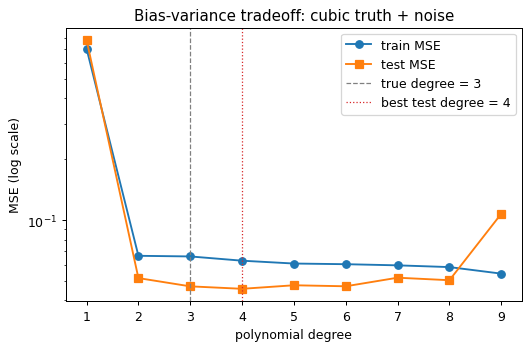

degree 1: train MSE = 0.7041, test MSE = 0.7784
degree 2: train MSE = 0.0665, test MSE = 0.0516
degree 3: train MSE = 0.0660, test MSE = 0.0470
degree 4: train MSE = 0.0629, test MSE = 0.0457
degree 5: train MSE = 0.0609, test MSE = 0.0475
degree 6: train MSE = 0.0605, test MSE = 0.0470
degree 7: train MSE = 0.0597, test MSE = 0.0518
degree 8: train MSE = 0.0585, test MSE = 0.0504
degree 9: train MSE = 0.0543, test MSE = 0.1074

Best test degree = 4 (true degree 3). All checks passed. ✓


In [7]:
train_mse, test_mse = [], []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    phi_train = poly.fit_transform(x_train.reshape(-1, 1))
    phi_test = poly.transform(x_test.reshape(-1, 1))
    model = LinearRegression().fit(phi_train, y_train)
    train_mse.append(np.mean((model.predict(phi_train) - y_train) ** 2))
    test_mse.append(np.mean((model.predict(phi_test) - y_test) ** 2))

best_degree = list(degrees)[int(np.argmin(test_mse))]

plt.figure(figsize=(6, 4))
plt.semilogy(degrees, train_mse, "o-", label="train MSE")
plt.semilogy(degrees, test_mse, "s-", label="test MSE")
plt.axvline(3, color="gray", ls="--", lw=1, label="true degree = 3")
plt.axvline(best_degree, color="tab:red", ls=":", lw=1, label=f"best test degree = {best_degree}")
plt.xlabel("polynomial degree")
plt.ylabel("MSE (log scale)")
plt.title("Bias-variance tradeoff: cubic truth + noise")
plt.legend()
plt.tight_layout()
plt.show()

for degree, tr, te in zip(degrees, train_mse, test_mse):
    print(f"degree {degree}: train MSE = {tr:.4f}, test MSE = {te:.4f}")

# Deterministic checks
assert np.all(np.diff(train_mse) <= 1e-10), "train MSE must not increase (nested models)"
assert test_mse[2] < test_mse[0], "degree 3 should beat degree 1 on test data (underfit)"
assert test_mse[8] > test_mse[2], "degree 9 should be worse than degree 3 on test data (overfit)"
assert 2 <= best_degree <= 6, f"best test degree should be near 3, got {best_degree}"
print(f"\nBest test degree = {best_degree} (true degree 3). All checks passed. \u2713")

---
## Exercise 5 — Failure Analysis: Unscaled Features Break Gradient Descent

The normal-equation solver is scale-invariant, but gradient descent is not: its speed
is governed by $\kappa(X^\top X)$, and its stability requires
$\eta < 2 / L_{\text{smooth}}$ with $L_{\text{smooth}} = \frac{2}{n}\sigma_1(X)^2$
(theory §11).

**Setup:** feature $x_1 \sim U(0, 1)$, feature $x_2 \sim U(0, 1000)$, and
$y = 3x_1 + 0.005 x_2 + 2 + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0, 0.1^2)$.

**Before running the cell below, predict:**

1. Roughly how large is $L_{\text{smooth}}$ for the unscaled design, and what does
   that force the learning rate to be?
2. With that tiny learning rate and 1000 iterations, which parameters barely move?
   What sign of $R^2$ do you expect?
3. After `standardize`, what happens to $\kappa(X^\top X)$ and to convergence?

**Then explain:** why does standardization change the *optimization landscape*
without changing the *minimum-achievable loss*?

In [8]:
from ml_first_principles.data_utils import standardize

rng_ex5 = np.random.default_rng(SEED)
n_ex5 = 100
X_ex5 = np.column_stack([rng_ex5.uniform(0.0, 1.0, n_ex5), rng_ex5.uniform(0.0, 1000.0, n_ex5)])
y_ex5 = X_ex5 @ np.array([3.0, 0.005]) + 2.0 + rng_ex5.normal(0.0, 0.1, n_ex5)

# Stability bound for the unscaled design (bias column included, as in the library)
design_ex5 = np.column_stack([np.ones(n_ex5), X_ex5])
L_smooth = (2.0 / n_ex5) * np.linalg.eigvalsh(design_ex5.T @ design_ex5).max()
print(f"cond(X^T X) unscaled  = {np.linalg.cond(design_ex5.T @ design_ex5):.2e}")
print(f"L_smooth unscaled     = {L_smooth:.2e}  ->  stable lr < {2.0 / L_smooth:.2e}")

# GD on raw features: the largest stable-ish lr is ~1e-6, far too small for the
# intercept/x1 directions to move in 1000 iterations
gd_unscaled = LinearRegression(solver="gd", lr=1e-6, max_iter=1000).fit(X_ex5, y_ex5)
r2_unscaled = gd_unscaled.score(X_ex5, y_ex5)
print(f"\nGD on unscaled X:     R^2 = {r2_unscaled:.4f}   coef = {gd_unscaled.coef_}, "
      f"intercept = {gd_unscaled.intercept_:.4f}")

# Standardize and refit with a healthy learning rate
X_ex5_scaled, mean_ex5, std_ex5 = standardize(X_ex5)
design_scaled = np.column_stack([np.ones(n_ex5), X_ex5_scaled])
print(f"\ncond(X^T X) scaled    = {np.linalg.cond(design_scaled.T @ design_scaled):.2e}")
gd_scaled = LinearRegression(solver="gd", lr=0.1, max_iter=1000).fit(X_ex5_scaled, y_ex5)
r2_scaled = gd_scaled.score(X_ex5_scaled, y_ex5)
print(f"GD on scaled X:       R^2 = {r2_scaled:.4f}   coef = {gd_scaled.coef_}, "
      f"intercept = {gd_scaled.intercept_:.4f}")

# Reference: the scale-invariant normal-equation solver on raw features
ols_ref = LinearRegression(solver="normal").fit(X_ex5, y_ex5)
print(f"Normal eq (raw X):    R^2 = {ols_ref.score(X_ex5, y_ex5):.4f}")

# Deterministic checks
assert r2_unscaled < 0.5, f"unscaled GD should fit poorly, got R^2 = {r2_unscaled:.4f}"
assert r2_scaled > 0.99, f"scaled GD should fit well, got R^2 = {r2_scaled:.4f}"
# Scaled-GD slopes agree with the closed form after undoing the standardization
assert np.allclose(gd_scaled.coef_ / std_ex5, ols_ref.coef_, atol=1e-3)
print("\nFeature-scaling failure case confirmed. \u2713")

cond(X^T X) unscaled  = 6.38e+06
L_smooth unscaled     = 6.71e+05  ->  stable lr < 2.98e-06

GD on unscaled X:     R^2 = -0.5965   coef = [0.00146473 0.0100673 ], intercept = 0.0018

cond(X^T X) scaled    = 1.32e+00
GD on scaled X:       R^2 = 0.9963   coef = [0.84269397 1.46287775], intercept = 5.9606
Normal eq (raw X):    R^2 = 0.9963

Feature-scaling failure case confirmed. ✓
